# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [1]:
import pandas as pd

# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 1.3 MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [2]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [3]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Your Work

## Data Exploration

### Target (`Recommended IND`)

In [12]:
df["Recommended IND"].value_counts()

Recommended IND
1    15053
0     3389
Name: count, dtype: int64

In [13]:
df["Recommended IND"].value_counts(normalize=True)

Recommended IND
1    0.816235
0    0.183765
Name: proportion, dtype: float64

**Class imbalance:** the target is skewed. About 82% of reviews are recommended (`1`) and only about 18% are not (`0`), roughly 4.4 to 1.

This matters because a model that always predicts "recommended" would reach about 82% accuracy without learning anything. So accuracy alone is misleading here. When evaluating, I will look at precision, recall and F1 for the minority class (`0`), and consider `class_weight='balanced'` and a stratified train/test split.

### Numerical Features

In [14]:
df[["Age", "Positive Feedback Count"]].describe()

,Age,Positive Feedback Count
count,18442.000000,18442.000000
mean,43.383635,2.697484
std,12.246264,5.942220
min,18.000000,0.000000
25%,34.000000,0.000000
50%,41.000000,1.000000
75%,52.000000,3.000000
max,99.000000,122.000000


**Numerical features summary:**
- `Age` ranges from 18 to 99 with a mean (43.4) close to the median (41), so it is only mildly right-skewed. The maximum of 99 may be worth a quick check.
- `Positive Feedback Count` is heavily right-skewed: the median is 1, the mean is 2.7, 75% of reviews have 3 or fewer, and the maximum is 122.
- Both columns have 18,442 non-null values, so there is no missing data.

In [15]:
df.groupby("Recommended IND")[["Age", "Positive Feedback Count"]].mean()

,Age,Positive Feedback Count
Recommended IND,,
0,42.437592,3.428740
1,43.596625,2.532851


In [16]:
df.groupby("Recommended IND")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Recommended IND,,,,,,,,
0,3389.0,42.437592,11.694862,19.0,34.0,41.0,50.0,91.0
1,15053.0,43.596625,12.357405,18.0,35.0,42.0,52.0,99.0


In [17]:
df.groupby("Recommended IND")["Positive Feedback Count"].describe()

,count,mean,std,min,25%,50%,75%,max
Recommended IND,,,,,,,,
0,3389.0,3.428740,6.698298,0.0,0.0,1.0,4.0,108.0
1,15053.0,2.532851,5.745748,0.0,0.0,1.0,3.0,122.0


**Numerical features vs. target:**
- `Age`: the distributions are very similar across the two classes. The means are close (about 42.4 for not recommended vs. 43.6 for recommended), and so are the quartiles (25%: 34 vs. 35, median: 41 vs. 42, 75%: 50 vs. 52) and spreads (std 11.7 vs. 12.4). Not-recommended reviewers skew very slightly younger, but the difference is small, so `Age` looks like a weak signal on its own. Whether it helps in combination with other features is something the model will show.
- `Positive Feedback Count`: the typical review looks the same in both classes (25% is 0 and the median is 1 for both). The difference is in the upper half: the 75% quartile is 4 for not recommended vs. 3 for recommended, and the mean is 3.4 vs. 2.5. The maximum is not higher for not-recommended reviews (108 vs. 122), so a few extreme reviews do not explain the gap. Not-recommended reviews get slightly more helpful votes, but the effect is modest, so this looks like a weak-to-moderate signal.

<Axes: >

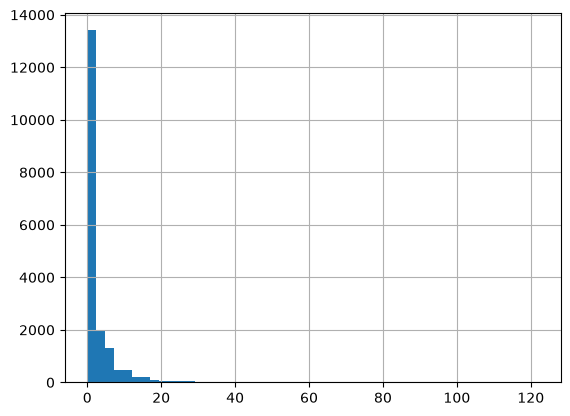

In [18]:
df["Positive Feedback Count"].hist(bins=50)

**Positive Feedback Count distribution:** the histogram shows the skew seen in `describe()`. Most reviews have very few helpful votes, with a long tail up to 122. A 0 here is a real count (no one marked the review helpful), not missing data. If a linear model is used, a log transform (`np.log1p`) before scaling may help.

In [19]:
review_length = df["Review Text"].str.split().str.len()

review_length.groupby(df["Recommended IND"]).describe()

,count,mean,std,min,25%,50%,75%,max
Recommended IND,,,,,,,,
0,3389.0,63.797875,26.687656,3.0,41.0,64.0,90.0,111.0
1,15053.0,62.145752,28.447011,2.0,38.0,62.0,90.0,115.0


**Review length (words) vs. target:** review length is very similar across the two classes. The medians are 64 (not recommended) vs. 62 (recommended), the 75% quartile is 90 for both, and the spreads are close (std 26.7 vs. 28.4). Not-recommended reviews are only slightly longer on average, so review length looks like a weak signal on its own and is probably not worth adding as a separate feature. The maximum is about 111-115 words in both classes, which suggests reviews may have been truncated in this dataset.

**Numerical features: signal summary**

| Feature | Evidence so far | Verdict |
|---|---|---|
| `Age` | The quartiles and spreads are almost identical across classes. | Weak |
| Review length | The medians are 64 vs. 62 words and the 75% quartile is 90 for both. | Weak, so it will not be added as a feature |
| `Positive Feedback Count` | The medians are the same (1), but the 75% quartile is 4 vs. 3 and the mean is 3.4 vs. 2.5 (not recommended vs. recommended). | Weak to moderate, the strongest numerical candidate |

### Categorical Features

In [20]:
cat_cols = ["Clothing ID", "Division Name", "Department Name", "Class Name"]

df[cat_cols].nunique()

Clothing ID        531
Division Name        2
Department Name      6
Class Name          14
dtype: int64

In [21]:
df["Division Name"].value_counts()

Division Name
General           11664
General Petite     6778
Name: count, dtype: int64

In [22]:
df["Department Name"].value_counts()

Department Name
Tops        8713
Dresses     5371
Bottoms     3184
Jackets      879
Intimate     188
Trend        107
Name: count, dtype: int64

In [23]:
df["Class Name"].value_counts()

Class Name
Dresses           5371
Knits             3981
Blouses           2587
Sweaters          1218
Pants             1157
Jeans              970
Fine gauge         927
Skirts             796
Jackets            598
Outerwear          281
Shorts             260
Lounge             188
Trend              107
Casual bottoms       1
Name: count, dtype: int64

In [24]:
df["Clothing ID"].value_counts().head(10)

Clothing ID
1078    871
862     658
1094    651
1081    487
829     452
872     450
1110    419
868     370
895     336
867     291
Name: count, dtype: int64

In [28]:
id_counts = df["Clothing ID"].value_counts()
rare_ids = id_counts < 5

print("Share of Clothing IDs with fewer than 5 reviews:", rare_ids.mean())
print("Share of all reviews belonging to those IDs:", id_counts[rare_ids].sum() / id_counts.sum())

Share of Clothing IDs with fewer than 5 reviews: 0.4651600753295669
Share of all reviews belonging to those IDs: 0.026135993926905975


In [25]:
df.groupby("Division Name")["Recommended IND"].agg(["mean", "count"]).sort_values("mean")

,mean,count
Division Name,,
General,0.813615,11664
General Petite,0.820744,6778


In [26]:
df.groupby("Department Name")["Recommended IND"].agg(["mean", "count"]).sort_values("mean")

,mean,count
Department Name,,
Trend,0.757009,107
Dresses,0.803202,5371
Tops,0.808791,8713
Intimate,0.835106,188
Jackets,0.840728,879
Bottoms,0.852701,3184


In [27]:
df.groupby("Class Name")["Recommended IND"].agg(["mean", "count"]).sort_values("mean")

,mean,count
Class Name,,
Trend,0.757009,107
Sweaters,0.795567,1218
Dresses,0.803202,5371
Knits,0.806330,3981
Blouses,0.809432,2587
Outerwear,0.822064,281
Shorts,0.830769,260
Fine gauge,0.834951,927
Lounge,0.835106,188


In [29]:
pd.crosstab(df["Department Name"], df["Class Name"])

Class Name,Blouses,Casual bottoms,Dresses,Fine gauge,Jackets,Jeans,Knits,Lounge,Outerwear,Pants,Shorts,Skirts,Sweaters,Trend
Department Name,,,,,,,,,,,,,,
Bottoms,0,1,0,0,0,970,0,0,0,1157,260,796,0,0
Dresses,0,0,5371,0,0,0,0,0,0,0,0,0,0,0
Intimate,0,0,0,0,0,0,0,188,0,0,0,0,0,0
Jackets,0,0,0,0,598,0,0,0,281,0,0,0,0,0
Tops,2587,0,0,927,0,0,3981,0,0,0,0,0,1218,0
Trend,0,0,0,0,0,0,0,0,0,0,0,0,0,107


In [30]:
from scipy.stats import chi2_contingency

for col in ["Division Name", "Department Name", "Class Name"]:
    p_value = chi2_contingency(pd.crosstab(df[col], df["Recommended IND"]))[1]
    print(col, "p-value:", p_value)

Division Name p-value: 0.23582329989151365
Department Name p-value: 2.3249782313109914e-08
Class Name p-value: 2.1780612354400845e-07


**Recommendation rate by category:**

- **How to read the tables above:** `mean` is the share of reviews in that category with `Recommended IND = 1`, and `count` is the number of reviews. Each rate is compared against the **overall rate of 81.6%** (15,053 recommended out of 18,442 reviews, from the target section). A category with no effect should sit close to 81.6%. Differences are in percentage points.
- `Division Name`: General is 81.4% and General Petite is 82.1%, both within 1 point of the overall rate. The chi-square test agrees (p = 0.24), so the difference is consistent with chance.
- `Department Name`: most departments are within about 4 points of 81.6%, and Bottoms is the highest at 85.3% (3.7 above, n=3,184). The chi-square test is significant (p = 2.3e-08), so the differences between departments are real, but the gaps are small.
- `Class Name`: Jeans is the strongest finding at 87.6% (6.0 above, n=970). Sweaters is 79.6% (2.0 below, n=1,218). The chi-square test is significant (p = 2.2e-07).
- Small categories: Trend has the lowest rate (75.7%, 5.9 below) but only 107 reviews, and Casual bottoms is 100% on a single review. These individual rates are too uncertain to trust. The chi-square test also assumes each category has enough rows, so the `Class Name` p-value is slightly less reliable because of Casual bottoms.
- **What the p-values do and do not show:** a small p-value means the rates differ across a column's categories by more than chance. It does not say which categories differ or how large the effect is, and with 18,442 rows even small gaps can be significant.
- **Department and Class overlap (confirmed by the crosstab):** every class appears under exactly one department, for example Jeans, Pants, Shorts, Skirts and Casual bottoms are all under Bottoms. `Class Name` is therefore a finer split of `Department Name`, and Class alone already determines Department.
- `Clothing ID`: it has 531 unique values (the top item has 871 reviews). 46.5% of the IDs have fewer than 5 reviews, but those IDs hold only 2.6% of all reviews, so encoding it is feasible. Whether it helps predict the target has not been checked.

**Categorical features: signal summary** (rates compared against the overall 81.6%)

| Feature | Evidence so far | Verdict |
|---|---|---|
| `Division Name` | Both divisions are within 1 point of 81.6% (81.4% and 82.1%); chi-square p = 0.24. | No signal |
| `Department Name` | Bottoms is highest at 85.3% (n=3,184), most others within about 4 points; chi-square p = 2.3e-08. | Small but real |
| `Class Name` | Jeans is 87.6% (n=970) and Sweaters is 79.6% (n=1,218); chi-square p = 2.2e-07. Small classes are too uncertain. | Small to moderate; fully nested in Department |
| `Clothing ID` | 531 unique values; 46.5% have fewer than 5 reviews but hold only 2.6% of rows. Not yet compared with the target. | Unknown |

### Text Features

In [31]:
for label in [0, 1]:
    print(f"--- Recommended IND = {label} ---")
    samples = df[df["Recommended IND"] == label].sample(3, random_state=27)
    for _, row in samples.iterrows():
        print(f"Title: {row['Title']}")
        print(f"Review: {row['Review Text']}\n")

--- Recommended IND = 0 ---
Title: Just ok.
Review: I found the color to be a bit blah, and the sweater is chunky and is a tad too short for wear it lands. also, because of its "chunkiness," it doesn't tuck in as nicely to a pair of jeans as it appears to on the model.

Title: Looks better on line
Review: I received this skirt today and was very disappointed. i don't know what i expected but it is not as i thought. even though the quality is very good and the fit is true to size, i may return it. the fabric of the skirt is just too busy, at least for me. i am just uncertain and even though i have many tops, the colors are just not matching. white looks better than any colored top with this particular print. i am going to try it on one more time and make a definite decision.

Title: Runs small, impossible zipper
Review: I ordered the red version--it is incredibly cute, soft, vibrant, and a flattering a-line. however, this dress is sized oddly, running at least one or two sizes too small

In [32]:
(df[["Title", "Review Text"]].apply(lambda col: col.str.strip() == "")).sum()

Title          0
Review Text    0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
from sklearn.feature_extraction.text import CountVectorizer


def top_words(texts, n=15):
    """Share of reviews that contain each word (stop words removed)."""
    vectorizer = CountVectorizer(stop_words="english", binary=True)
    counts = vectorizer.fit_transform(texts)
    share = pd.Series(
        counts.sum(axis=0).A1 / counts.shape[0],
        index=vectorizer.get_feature_names_out(),
    )
    return share.sort_values(ascending=False).head(n)


for label in [0, 1]:
    print(f"--- Recommended IND = {label} ---")
    print(top_words(df.loc[df["Recommended IND"] == label, "Review Text"]), "\n")

--- Recommended IND = 0 ---
like        0.350546
fit         0.279138
dress       0.273532
just        0.261434
fabric      0.258778
size        0.229861
look        0.209501
love        0.200059
ordered     0.195338
really      0.184420
small       0.177634
color       0.166421
wear        0.161995
material    0.161405
way         0.142520
dtype: float64 

--- Recommended IND = 1 ---
love          0.357337
size          0.317611
dress         0.286189
fit           0.285524
wear          0.269714
great         0.254634
like          0.245732
just          0.205740
color         0.191723
fabric        0.177639
perfect       0.176244
little        0.163223
small         0.163024
flattering    0.161031
soft          0.155783
dtype: float64 



## Building Pipeline

## Training Pipeline

## Fine-Tuning Pipeline